# Dataset: AB_NYC_2019

## Author: Emmanuel Aregbesola
## Date: March 2026

In [1]:
# import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load in the clean dataset

df = pd.read_csv('airbnb_cleaned.csv')

# 1. Basic Inspection

In this section, we will confirm the validity of the cleaned dataset. To do that, we will do the following;

1. Shape.
2. Column Names.
3. Data types.
4. Summary statistics.
5. Null values.

In [3]:
# validate the shape of the dataset

df.shape

(48768, 16)

In [4]:
# validate the column names

df.columns.to_list()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [5]:
# validate the data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48768 entries, 0 to 48767
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48768 non-null  int64  
 1   name                            48768 non-null  object 
 2   host_id                         48768 non-null  int64  
 3   host_name                       48768 non-null  object 
 4   neighbourhood_group             48768 non-null  object 
 5   neighbourhood                   48768 non-null  object 
 6   latitude                        48768 non-null  float64
 7   longitude                       48768 non-null  float64
 8   room_type                       48768 non-null  object 
 9   price                           48768 non-null  int64  
 10  minimum_nights                  48768 non-null  int64  
 11  number_of_reviews               48768 non-null  int64  
 12  last_review                     

In [6]:
# validate the null values present

df.isna().sum()

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       9935
reviews_per_month                 9935
calculated_host_listings_count       0
availability_365                     0
dtype: int64

In [7]:
# validate the summary statistics

df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.876800e+04,4.876800e+04,48768.000000,48768.000000,48768.000000,48768.000000,48768.000000,38833.000000,48768.000000,48768.000000
mean,1.900155e+07,6.750893e+07,40.728939,-73.952182,152.647556,7.006049,23.327346,1.373128,7.021448,112.485277
std,1.098377e+07,7.854996e+07,0.054565,0.046137,239.966651,20.519770,44.589808,1.680391,32.530641,131.455071
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.458954e+06,7.798076e+06,40.690027,-73.983072,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.965461e+07,3.072157e+07,40.723050,-73.955660,105.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.913342e+07,1.074344e+08,40.763130,-73.936287,175.000000,5.000000,24.000000,2.020000,2.000000,226.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [8]:
# convert to right datatype

df['last_review'] = pd.to_datetime(df['last_review'])
df['id'] = df['id'].astype(str)
df['host_id'] = df['host_id'].astype(str)

In [9]:
# validate change in datatype

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48768 entries, 0 to 48767
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48768 non-null  object        
 1   name                            48768 non-null  object        
 2   host_id                         48768 non-null  object        
 3   host_name                       48768 non-null  object        
 4   neighbourhood_group             48768 non-null  object        
 5   neighbourhood                   48768 non-null  object        
 6   latitude                        48768 non-null  float64       
 7   longitude                       48768 non-null  float64       
 8   room_type                       48768 non-null  object        
 9   price                           48768 non-null  int64         
 10  minimum_nights                  48768 non-null  int64         
 11  nu

## Summary of basic inspection

Loaded the cleaned dataset and cross-checked shape, columns, null values, and data types 
against the cleaning notebook. Everything checks out as expected.

Two dtype corrections were made upon loading:
- `last_review` — converted back to datetime (CSV format does not preserve datetime, reverts to object on save)
- `id` and `host_id` — converted from int to object since they are identifiers, not numeric columns

# 2. Explorative Data Analysis

## 2.1 Univariate Analysis

### 2.1.1 Price

In [10]:
# Get the summary statistics for price

df['price'].describe()

count    48768.000000
mean       152.647556
std        239.966651
min         10.000000
25%         69.000000
50%        105.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [11]:
# check for outlier

print(df['price'].quantile(0.90))  # 90th percentile
print(df['price'].quantile(0.95))  # 95th percentile
print(df['price'].quantile(0.99))  # 99th percentile

269.0
355.0
799.0


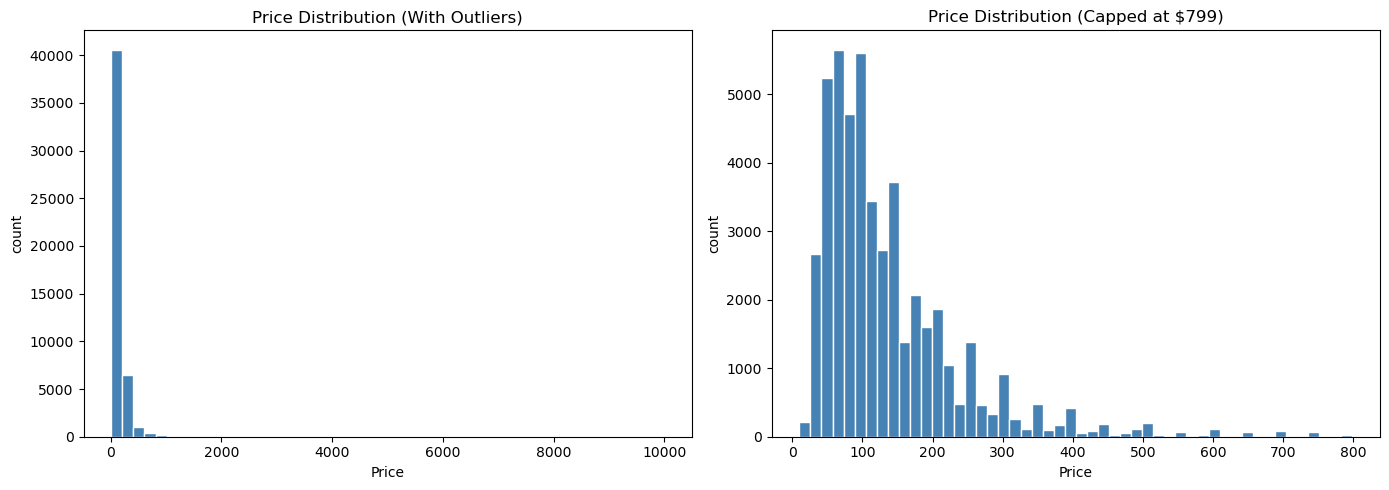

In [12]:
# plot the distribution graph for prices with and without outliers

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
ax[0].set_title('Price Distribution (With Outliers)')
ax[0].set_xlabel('Price')
ax[0].set_ylabel('count')

filtered = df[df['price'] <= 799]
ax[1].hist(filtered['price'], bins=50, color='steelblue', edgecolor='white')
ax[1].set_title('Price Distribution (Capped at $799)')
ax[1].set_xlabel('Price')
ax[1].set_ylabel('count')

plt.tight_layout()
plt.show()

## Findings

From our summary statistics, the median is `$105.0` and the mean is `$152.65`. This shows that the mean is being pulled upward by luxury outliers and the median is the better representative of a typical NYC Airbnb listing price.     

After checking the percentile, it is noticed that the 99th percentile is `$799`. It is also known, from the summary statistics that the maximum listing price is `$10000`. With these information, we come to the conclusion that our outliers will start from `$799`.

Since we know that there are outliers, we decided to plot two graphs.   
The left -- The graph with outliers, we can see how the outliers stretches out on the x-axis pushing most of the listings far left.     
The right -- the graph without outliers, here we notice that most listing price cluster are within the range `$50` and `$150`
The price distribution is heavily right skewed.

=====================================================================================================================

### 2.1.2 Availability_365

In [13]:
# Check the summary statistics for availability

df['availability_365'].describe()

count    48768.000000
mean       112.485277
std        131.455071
min          0.000000
25%          0.000000
50%         45.000000
75%        226.000000
max        365.000000
Name: availability_365, dtype: float64

In [14]:
# check the count and mean of zero availability

print((df['availability_365'] == 0).sum())
print((df['availability_365'] == 0).mean() * 100)

17505
35.89443897637795


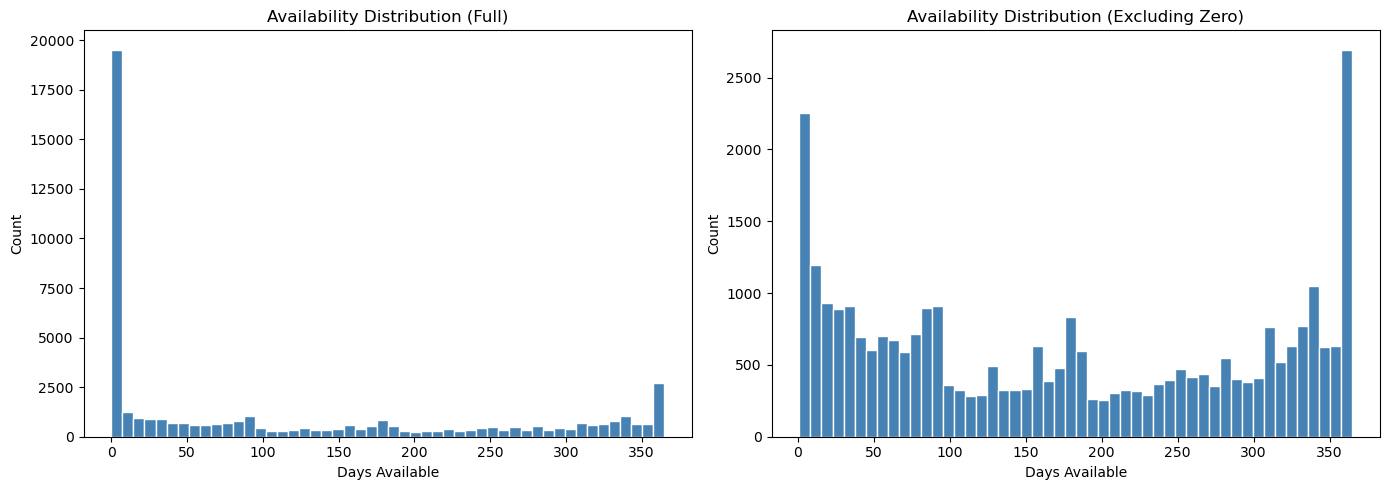

In [15]:
# plot the distribution of the listing days with and without zero listings

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# with zero availability
axes[0].hist(df['availability_365'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Availability Distribution (Full)')
axes[0].set_xlabel('Days Available')
axes[0].set_ylabel('Count')

# without zero availability
filtered_avail = df[df['availability_365'] > 0]
axes[1].hist(filtered_avail['availability_365'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Availability Distribution (Excluding Zero)')
axes[1].set_xlabel('Days Available')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Findings

From our summary statistics, we noticed that at least `25%` of our listing have no availability. These can be caused by;
1. Host temporarily blocked all dates
2. The dates of the listings have been booked
3. Host paused the listing temporarily

The median day for listing is `45 days`, the mean is `112 days`. The median will be a better representative for a typical availability for listings as mean is pulled upward by fully available listings (365 days).

Diving deeper into the zero availability, 35.9% of all the listings have no availability    


Our distribution shows us a bimodal pattern -- two distinct group of hosting behaviour.       
The left -- we have availability distribution of all listings. This shows us 35.9%, which is, our zero listing is dominating the plot making other listing flat.       
The right -- we have availability distribution of all listing excluding the zero availability. We can see that there are two distinct behaviour. at the low end, we have availabilty at 1-10 days and at the other end we have availability at 365 days.

To note, the median can be misleading. From our visualization, we can conclude that listing availabilty can fall between `0`, `1-10`, or `365` days.

=====================================================================================================================

### 2.1.3 Minimum_nights

In [16]:
# get the summary statistics of minimum_nights

df['minimum_nights'].describe()

count    48768.000000
mean         7.006049
std         20.519770
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [17]:
# check for listings above 365 days

min_valid_check = df[df['minimum_nights'] > 365]
min_valid_check.count()

id                                14
name                              14
host_id                           14
host_name                         14
neighbourhood_group               14
neighbourhood                     14
latitude                          14
longitude                         14
room_type                         14
price                             14
minimum_nights                    14
number_of_reviews                 14
last_review                        6
reviews_per_month                  6
calculated_host_listings_count    14
availability_365                  14
dtype: int64

In [18]:
# check the minimum stay at 95th percentile

print(df['minimum_nights'].quantile(0.95))

30.0


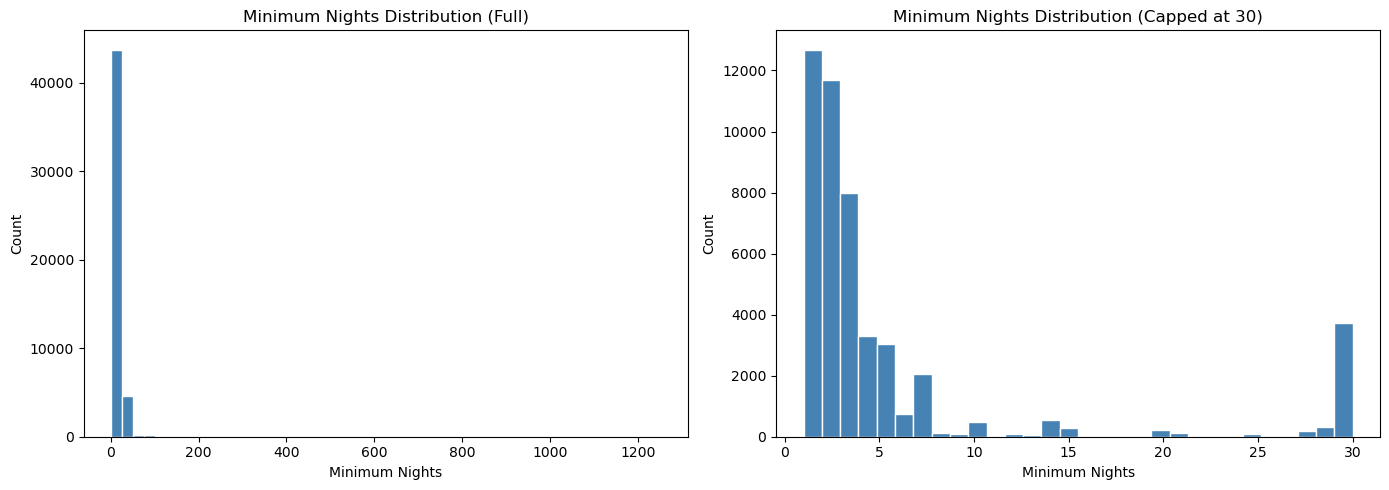

In [19]:
# plot the distribution of minimum_nights with full nights and nights capped at 30 days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# full distribution
axes[0].hist(df['minimum_nights'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Minimum Nights Distribution (Full)')
axes[0].set_xlabel('Minimum Nights')
axes[0].set_ylabel('Count')

# capped at 95th percentile
filtered_nights = df[df['minimum_nights'] <= 30]
axes[1].hist(filtered_nights['minimum_nights'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Minimum Nights Distribution (Capped at 30)')
axes[1].set_xlabel('Minimum Nights')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Findings

From our summary statistics, we can see that we have a median value of `3` days and a mean value of `7` days. Median will be a better representative of a typical stay at the listing as the mean is being pulled upward by stays longer than `365` days.    
We can also see that the maximum stay is 1250 days which is over 3 years stay.

We checked for listings above `365` days. There are 14 listings that are over `365` days. These listings should be flagged as they are not short-term leasing but some sort of long-term agreement listing.

We are filtering our dataset at the 95th percentile as anything above that is a form of long-term rental.

After plotting the distribution, here are our findings.         
Left -- Our distribution is pushed to the right because of the extreme values have stretched out the x-axis making everything else invisible.             
Right -- We have a strong right-skewed distribution. Most of the listings have either `1-3` days or `30` days minimum nights. This shows that the hosts either opt for short-term stay or a monthly stay for customers.

=====================================================================================================================

## 2.1.4. Number_of_reviews

In [20]:
# summary statistics for number_of_reviews

df['number_of_reviews'].describe()

count    48768.000000
mean        23.327346
std         44.589808
min          0.000000
25%          1.000000
50%          5.000000
75%         24.000000
max        629.000000
Name: number_of_reviews, dtype: float64

In [21]:
# check the sum and mean of zero reviews

print((df['number_of_reviews'] == 0).sum())
print((df['number_of_reviews'] == 0).mean() * 100)

9935
20.371965223097114


In [22]:
# check the 95th and 99th percentile of number_of_review

print(df['number_of_reviews'].quantile(0.95))
print(df['number_of_reviews'].quantile(0.99))

114.0
214.0


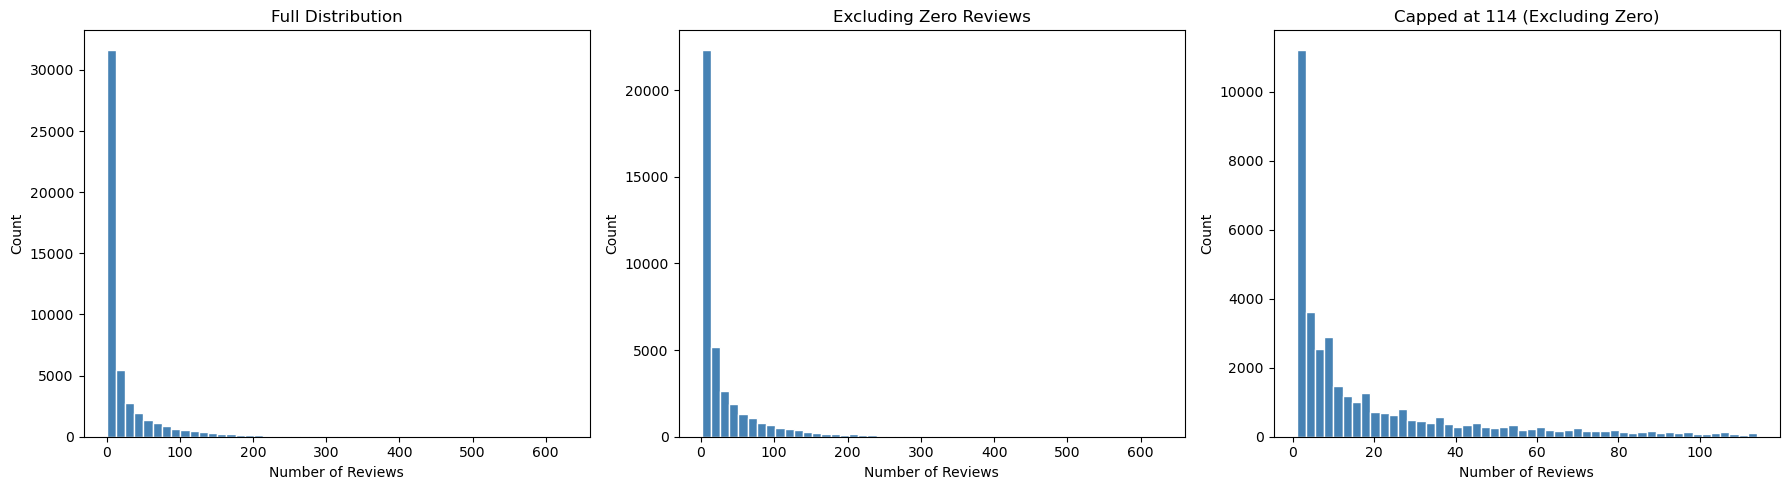

In [23]:
# plot the distribution 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# full distribution
axes[0].hist(df['number_of_reviews'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Full Distribution')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Count')

# excluding zero
filtered_no_zero = df[df['number_of_reviews'] > 0]
axes[1].hist(filtered_no_zero['number_of_reviews'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Excluding Zero Reviews')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Count')

# capped at 95th percentile, excluding zero
filtered_capped = df[(df['number_of_reviews'] > 0) & (df['number_of_reviews'] <= 114)]
axes[2].hist(filtered_capped['number_of_reviews'], bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Capped at 114 (Excluding Zero)')
axes[2].set_xlabel('Number of Reviews')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Findings

From our summary, we can see a mean of `23` number of reviews and a median of `5` number of reviews. What is interesting is the standard deviation of `44.5` number of reviews. Small number of listings have a high number of reviews while majority of listings have a small number of reviews.    
Also `20.4%` of listings have not been reviewed. That is 1 in 5 listings with zero booking history.

We are capping our dataset at the 95th percentile to take care of outliers

From the plot of our distribution
Left -- There is a large spike at zero — 20.4% of listings never reviewed. Extreme right skew with tail stretching to 629.     
Middle (excluding zero) -- Spike moves to 1-5 reviews. Still heavily right skewed — most active listings have very few reviews, a small number have hundreds.      
Right (capped at 114) -- Clearest view — overwhelming majority of active listings have between 1-10 reviews. Reviews drop off sharply after that.

This corroborate with our story that majority of the listings have few reviews and few listings have the majority of the reviews.

=====================================================================================================================

## 2.2 Multivariate Analysis

### 2.2.1. Price Vs Room Type

In [24]:
# Check the median price across all room_type

df.groupby('room_type')['price'].agg('median')

room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0
Name: price, dtype: float64

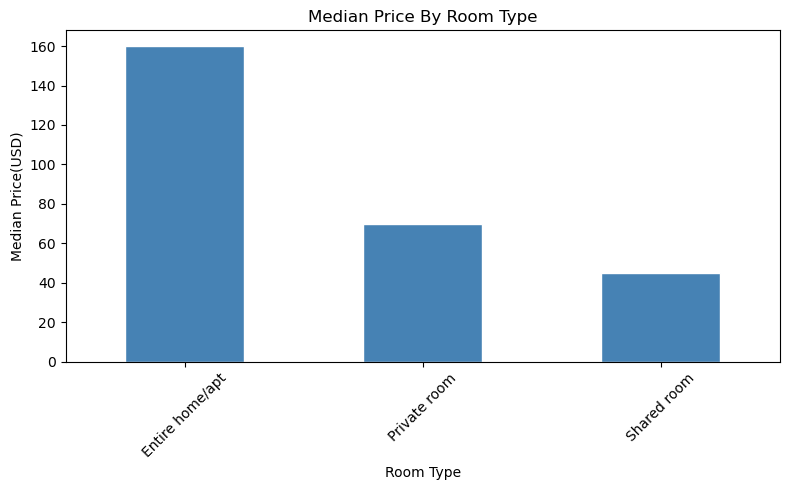

In [25]:
# plot the distribution of the median price across all room_type

room_median = df.groupby('room_type')['price'].agg('median')

plt.figure(figsize=(8,5))
room_median.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Median Price By Room Type')
plt.xlabel('Room Type')
plt.ylabel('Median Price(USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Findings

Entire home/apt commands a median price of `$160`, more than double that of a private room 
`$70` and over three times a shared room `$45`. This makes intuitive sense — the more space 
and privacy a listing offers, the higher the price.     
Hosts price accordingly and customers 
pay the premium for exclusivity.

=====================================================================================================================

### 2.2.2. Price Vs Neighbourhood_group

In [26]:
# check for the count and median price across all neighbourhood_group

df.groupby('neighbourhood_group')['price'].agg(Count= 'count',
                                               Median = 'median')

,Count,Median
neighbourhood_group,,
Bronx,1090,65.0
Brooklyn,20067,90.0
Manhattan,21592,150.0
Queens,5646,75.0
Staten Island,373,75.0


In [27]:
# get the percentage of listings of both Manhattan and Brooklyn

total = df['neighbourhood_group'].count()
manhattan_brooklyn = (21592 + 20067) / total * 100
print(manhattan_brooklyn)

85.42281824146981


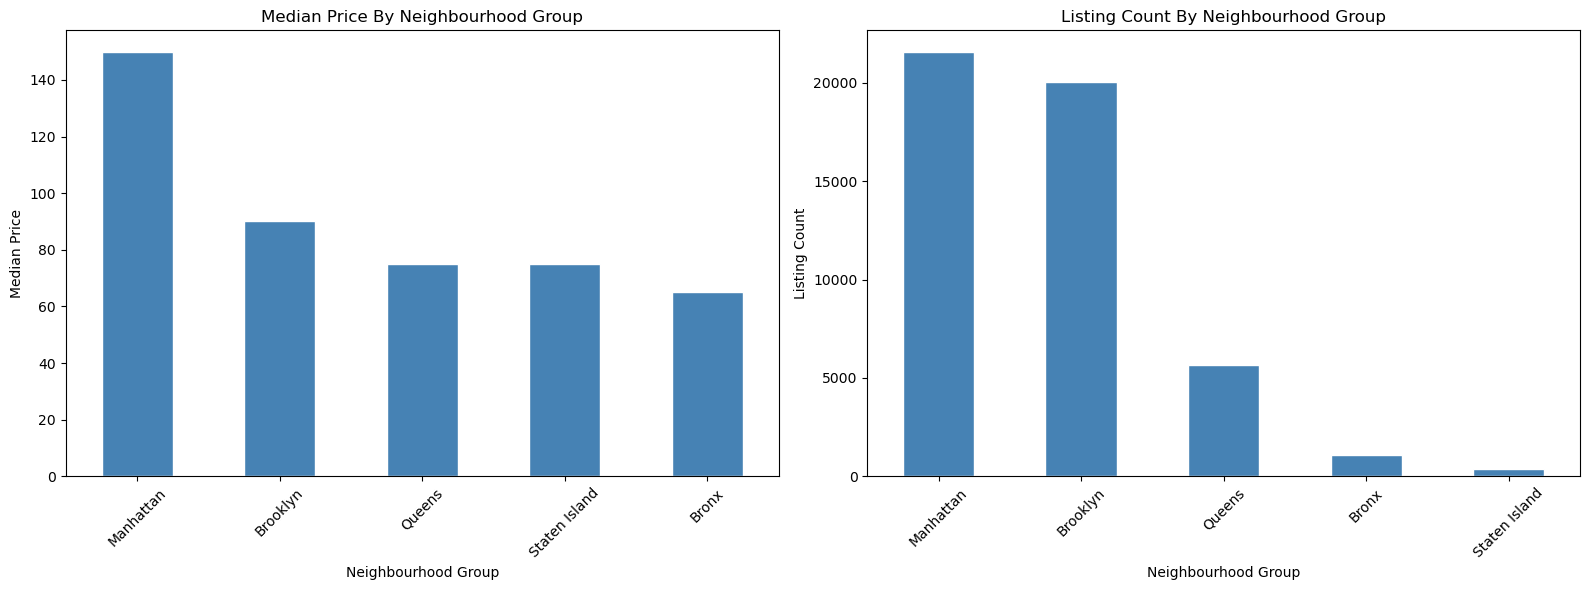

In [28]:
# plot the distribution of the count and median price across all neighbourhood_group

figs, axes = plt.subplots(1, 2, figsize=(16,6))

# Distribution for median
median_group = df.groupby('neighbourhood_group')['price'].agg('median').sort_values(ascending=False)
median_group.plot(kind='bar', color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Median Price By Neighbourhood Group')
axes[0].set_xlabel('Neighbourhood Group')
axes[0].set_ylabel('Median Price')
axes[0].tick_params(axis='x', rotation=45)

# Distribution for count
median_group = df.groupby('neighbourhood_group')['price'].agg('count').sort_values(ascending=False)
median_group.plot(kind='bar', color='steelblue', edgecolor='white', ax=axes[1])
axes[1].set_title('Listing Count By Neighbourhood Group')
axes[1].set_xlabel('Neighbourhood Group')
axes[1].set_ylabel('Listing Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Findings
Manhattan dominates both in listing count (21,592) and median price ($150) — the most 
expensive and most listed borough in NYC. Brooklyn follows closely with 20,067 listings 
at a median price of `$90`.

Together, Manhattan and Brooklyn account for 85.4% of all listings, showing that the 
NYC Airbnb market is heavily concentrated in these two boroughs.

The Bronx and Staten Island are significantly underrepresented — 1,090 and 373 listings 
respectively — and both carry lower median prices, reflecting their distance from tourist 
and business activity centres.

=====================================================================================================================

### 2.2.3 Neighbourhood_group Vs Number_of_reviews

In [29]:
# create a dataframe by filtering the zero from number_of_reviews
# exclude unreviewed listings to avoid skewing median

active_listings = df[df['number_of_reviews'] > 0]
active_listings.groupby('neighbourhood_group')['number_of_reviews'].agg('median')

neighbourhood_group
Bronx            15.0
Brooklyn          9.0
Manhattan         8.0
Queens           13.0
Staten Island    20.0
Name: number_of_reviews, dtype: float64

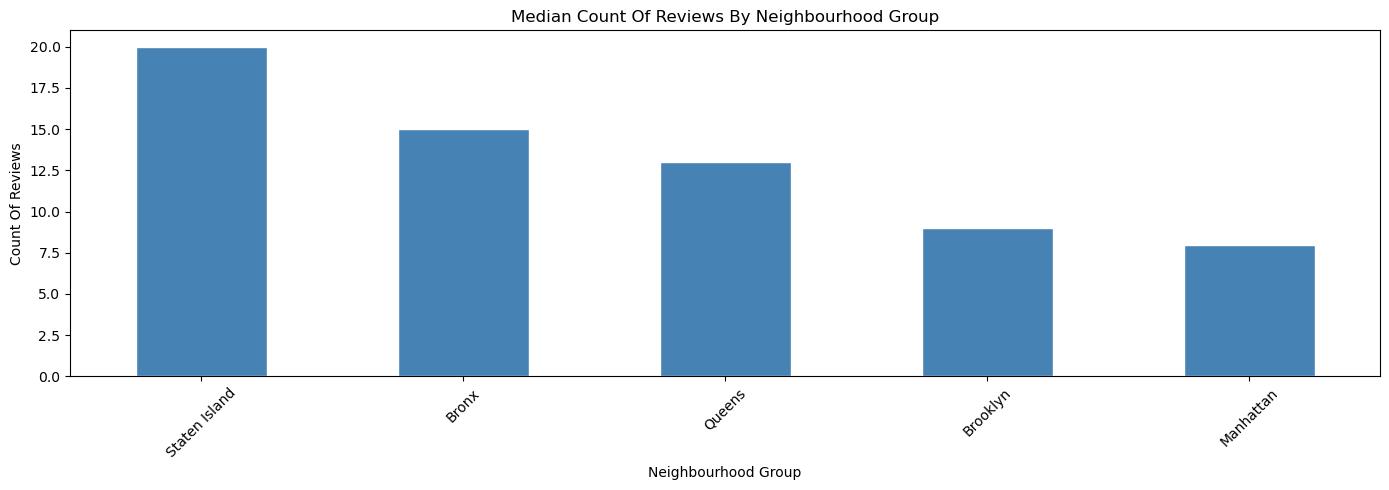

In [30]:
# plot the distribution the median count of reviews by neighbourhood group

median_listing = active_listings.groupby('neighbourhood_group')['number_of_reviews'].agg('median').sort_values(ascending=False)

plt.figure(figsize=(14,5))
median_listing.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Median Count Of Reviews By Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Count Of Reviews')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Findings

Staten Island has the highest median reviews `20` but the lowest listing count and lower prices. Manhattan has the highest prices but one of the lowest median review counts `8`

This tell us that for Manhattan;
More listings = more competition = reviews concentrated among top performers = lower median.

for Staten Island;
Fewer listings = less competition = reviews spread more evenly = higher median.

=====================================================================================================================

### 2.2.4 Price Vs Availability

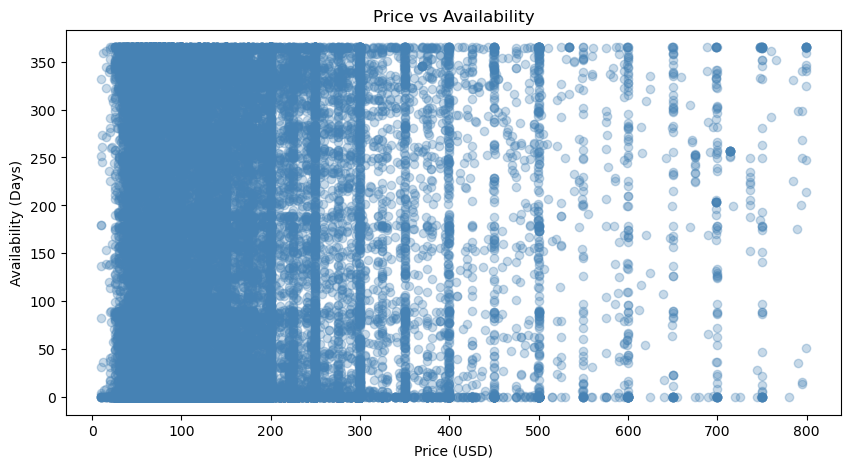

In [31]:
# filter out the otlier
filtered = df[df['price'] <= 799]

# plot the distribution of price and availability
plt.figure(figsize=(10, 5))
plt.scatter(filtered['price'], filtered['availability_365'], 
            color='steelblue', alpha=0.3)
plt.title('Price vs Availability')
plt.xlabel('Price (USD)')
plt.ylabel('Availability (Days)')


plt.show()

In [32]:
print(filtered[['price', 'availability_365']].corr())

                    price  availability_365
price             1.00000           0.11272
availability_365  0.11272           1.00000


## Findings

The scatter plot shows no clear visual pattern between price and availability. 
The Pearson correlation coefficient of `0.112` confirms a weak positive relationship — 
meaning higher priced listings are not booking faster than cheaper ones.

Price alone does not predict availability in this dataset.

=====================================================================================================================

### 2.2.5 Price Vs Reviews

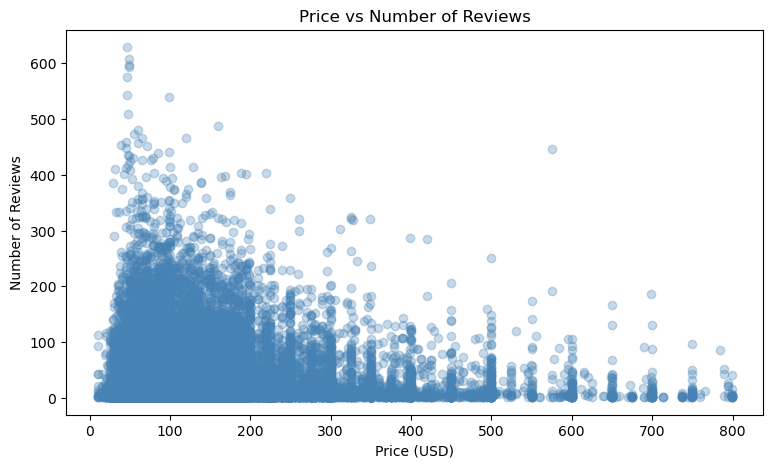

In [33]:
# filter with price <= $799 and number_of_reviews > 0
filtered_reviews = df[(df['price'] <= 799) & (df['number_of_reviews'] > 0)]

# plot the relationship
plt.figure(figsize=(9, 5))
plt.scatter(filtered_reviews['price'], filtered_reviews['number_of_reviews'], 
            color='steelblue', alpha=0.3)
plt.title('Price vs Number of Reviews')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Reviews')

plt.show()

In [34]:
print(filtered_reviews[['price', 'number_of_reviews']].corr())

                      price  number_of_reviews
price              1.000000          -0.040114
number_of_reviews -0.040114           1.000000


## Findings

`price` and `number_of_reviews` from the plot shows a pattern -- as price increases, reviews drop but we have to know how strong the relationship is by using correlation.

The correlations `-0.04` shows that there is a weak negative relationship between `price` and `number_of_reviews`

Also, the visual pattern is largely explained by density — there are significantly more low-priced listings than high-priced ones, making the lower price range appear more active.

=====================================================================================================================

### 2.2.6 what percentage of hosts have more than 5 listings?

In [35]:
# calculate the percentage of host with more than 5 listings

total_hosts = df['host_id'].nunique()
multi_hosts = df[df['calculated_host_listings_count'] > 5]['host_id'].nunique()
print((multi_hosts / total_hosts) * 100)

0.9213513152623849


In [36]:
# get the percentage of listings with more than 5 listings

total_listings = len(df)
multi_listings = df[df['calculated_host_listings_count'] > 5].shape[0]
print((multi_listings / total_listings) * 100)

9.666174540682416


## Findings

Only 0.92% of hosts have more than 5 listings, yet they account for 9.66% of all listings 
on the platform. This small group of professional operators have a lot of presence in the market.

The overwhelming majority of hosts (99%+) are casual hosts with 5 or fewer listings — 
likely individuals renting out their own home or spare room rather than running a rental business.

=====================================================================================================================

### 2.2.7 Do hosts with multiple listings charge more or less than single listing hosts?

In [37]:
# copy the filtered price df
filtered = df[df['price'] <= 799].copy()

# feature engineering host_type into multi and single hosts
filtered['host_type'] = filtered['calculated_host_listings_count'].apply(
    lambda x: 'Multi' if x > 1 else 'Single'
)

# get the median for host_type
filtered.groupby('host_type')['price'].median()

host_type
Multi      90.0
Single    115.0
Name: price, dtype: float64

In [38]:
# get the median for host_type per room_type

filtered.groupby(['host_type', 'room_type'])['price'].median()

host_type  room_type      
Multi      Entire home/apt    175.0
           Private room        67.0
           Shared room         38.0
Single     Entire home/apt    151.0
           Private room        70.0
           Shared room         65.0
Name: price, dtype: float64

## Findings

When you look at the overall median price, single hosts `($115)` charged more than multi hosts `($90)`. 
That didn't feel right, a full story was needed. So, the median price was then separated by `room_type`.


When you check by `room_type`, you will notice that, multi hosts charge more for entire homes `($175 vs $151)`. 
This makes more sense because professionals would know the market better and price more aggressively.


For shared rooms, singles hosts charge significantly more `($65 vs $38)`. 
This could be because single hosts listing a shared room is renting out of their own home. 
This means that they are charging more because the space is more personal. 
While multi hosts will most likely keep the prices low to maintain occupancy

The overall difference was driven by room type mix — multi hosts tend to have more private and shared rooms in their portfolios, pulling their overall median down. 
Controlling for room type reveals a clearer picture.

=====================================================================================================================

## 3. Geospatial

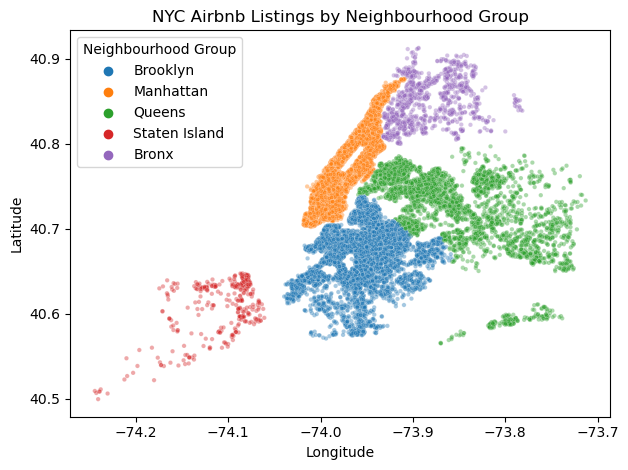

In [39]:
sns.scatterplot(data=df, x='longitude', y='latitude', hue='neighbourhood_group', alpha=0.4, s=10)

plt.title('NYC Airbnb Listings by Neighbourhood Group')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Neighbourhood Group')

plt.tight_layout()
plt.show()

## Findings

The plot above expresses and perfectly explains some of the previous findings. 
Staten's Island is isolated from the rest of the boroughs -- physically disconnected.
This explains why it is underrepresented in listings.

From the plot, it can be seen that Manhattan and Brooklyn's listings are very clustered and quite different from other boroughs which are a bit spread apart.

Queens is the largest borough geographically which is visible in the plot but the listing count doesn't reflect size, it reflects tourism demand.

=========================================================================================================

## 4. Honest Interpretation

### 4.1. Price(Mean Vs Median)

The mean price of `$152.65` and median of `$105.00` tell two different stories. 
A `$47.65` gap between them is not noise — it is a signal that the distribution is skewed 
by extreme values. Listings priced at `$799+` (above the 99th percentile) and outliers up 
to $10,000 pull the mean upward, making the average NYC listing appear significantly more 
expensive than it actually is.

Someone relying on the mean would conclude the typical listing costs `~$153`. 
In reality, half of all listings are priced at `$105` or below. The mean would mislead 
a host setting a competitive price or a traveller budgeting for a trip.

Median is the honest measure here — it is resistant to outliers and accurately represents 
what a typical NYC Airbnb listing actually costs.

### 4.2. Price Vs Review (correlation)

* A causes B - Price causes reviews (or lack of): If the price is low to begin with, this might drive in more customers and vice versa 

* B causes A - The more reviews a listing gets, the more credibility it gets, the more bookings, the higher the price. 

* Confounding variable C - It is clear that places like Manhattan or Brooklyn are hotspots for tourism. which means because listing are in this borough are likely to be high in both price and reviews.

But also, Manhattan had lower median reviews despite high prices. So geography drives price yes, but not necessarily reviews in the same direction

### 4.3. A Deceptive Analysis

Deceptive version: **"Single hosts charge more than professional multi-hosts — suggesting casual hosts price more aggressively."**      
Honest version: **This disappears when you control for room type...**

From the results, the analysis would be interpreted that single listing hosts charged significantly more `27.78%` higher than multiple listings host.

But instinctively that was wrong, 27.78% was a huge gap. The reason being muliple listings host are considered to be more professional than single listing hosts when it comes to the market and pricing.

It was then divided by `room_type` which showed us the full picture. When it comes to shared room, single listing hosts charged more than by `71.1% `more than multiple listings host. While for entire home, multiple listings host charged more than single listings host and for private rooms, there was no much difference.

So, it can be said that because a shared space is more of the single host's personal space. They list it at higher price.

In [40]:
# percentage of single host charging more

(115 - 90) / 90 * 100

27.77777777777778

In [41]:
# percentage of single host charging more (shared room)

(65 - 38) / 38 * 100

71.05263157894737

# Summary

### Pricing

* The typical NYC Airbnb listing costs `$105` (median), not `$153` (mean). The mean is distorted by luxury outliers up to `$10,000`.        
* Price is strongly tied to room type: entire homes `($160)` cost more than double private rooms `($70)` and over triple shared rooms ($45).
* Manhattan is the most expensive borough `($150 median)` and the most listed (21,592 listings).     

### Listings Distribution

* Manhattan and Brooklyn together account for 85.4% of all listings — the market is geographically concentrated.
* Staten Island is physically isolated and severely underrepresented (373 listings) despite having the highest median review count.

### Availability

* 35.9% of listings have zero availability — over 1 in 3 listings are either fully booked, paused, or blocked.
* Active listings cluster at two extremes: very low availability (1–10 days) or fully open (365 days). The median of 45 days is misleading — it doesn't represent either group well.

### Reviews

* 20.4% of listings have never been reviewed — 1 in 5 listings has no booking history.
* Staten Island's low competition explains its high median reviews (20), while Manhattan's high competition suppresses its median (8).
* Price and reviews have a weak negative correlation (-0.04) — price alone does not predict booking activity.

### Host Behaviour

* Only 0.92% of hosts own more than 5 listings, yet they control 9.66% of all listings.
* Multi-hosts charge more for entire homes `($175 vs $151)` but less for shared rooms `($38 vs $65)` — professional hosts price to maximise occupancy, personal hosts price their space as personal.